# A spin wave that stays

A long-wavelength magnetic texture is one of the few things a first-principles
calculation is asked for and usually cannot give: a spin density wave in
chromium has a period of twenty-one unit cells, a helix in a layered halide a
dozen, and a supercell pays the same price per degree of freedom for the slow
turning of the moments as for the atoms themselves. The ultracell handles the
length scale, and that is the subject of *A modulation over many unit cells*.
This notebook is about the other half of the problem, which is getting the
calculation into the wave at all.

The difficulty is a short one. Nothing in a self-consistent calculation breaks
spin symmetry on its own, so a long cell built out of a ferromagnetic unit cell
inherits that cell's magnetization unchanged, and the tiled state is an exact
solution of the long cell's own equations however many cells it has. A wave
therefore has to come from somewhere. One way is to push: apply a modulated
magnetic field and measure how far the magnet twists, which is a response.
The other is to hand the calculation the texture as its starting point and let
it keep it, which is what an ordered state is.

Both waves below are of the second kind. On a simple cubic hydrogen lattice the
staggered wave comes out **three millirydberg per unit cell below** the ferromagnet it was
started from, and a helix keeps its ninety degrees per cell to three decimal
places and, built from the unit cell's states and their time-reversed partners,
lands **within two thousandths of a millirydberg** of a real supercell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from defumat import Calculator

cal = Calculator.from_file('../tests/data/qe/h-mag-ultracell.in',
                           pseudo_dir='../tests/data/pseudo')

tiled = cal.get_ultracell(supercell=(2, 1, 1), kgrid=(2, 2, 2), nbnd=24)
print(f'{tiled.iterations} iteration, and the two cells hold',
      np.round(tiled.cell_moments(), 4), 'Bohr magnetons each')

[defumat] an ultracell calculation: no ground state cached, running the SCF first (conv_thr = 1e-11). Call get_scf() to do this explicitly.


1 iteration, and the two cells hold [0.6234 0.6234] Bohr magnetons each


One iteration, and the two moments are the unit cell's own. That is the point
being made rather than a run that failed: the tiled state solves the long cell's
equations exactly, so there is nothing for the iteration to do and no amount of
patience will produce a wave.

## Handing over the texture

The texture is given as a factor on the moment the unit cell already has, a
number at every point of the long cell for a collinear calculation, and it is
the same quantity `starting_magnetization` is for an atom one level down: a
fraction of a moment that is already there, between minus one and one. A factor
larger than one asks for more magnetization than the cell has and is refused.

One period of a cosine over two cells puts the two atoms' moments antiparallel,
which is the shortest wave a crystal has.

In [2]:
# the wave as a factor on the moment each cell already carries
stagger = lambda x: np.cos(np.pi * x[..., 0])

wave = cal.get_ultracell(supercell=(2, 1, 1), kgrid=(2, 2, 2), nbnd=24,
                         seed_magnetization=stagger)

gain = (tiled.total_energy - wave.total_energy) * 1000
print(f'{wave.iterations} iterations, and the staggered wave sits {gain:.3f}'
      ' mRy per cell below the ferromagnet')

8 iterations, and the staggered wave sits 3.017 mRy per cell below the ferromagnet


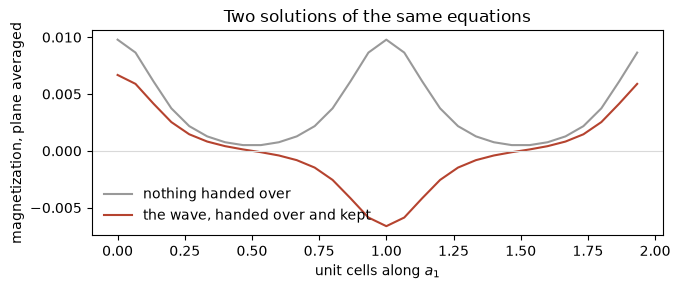

In [3]:
box = tiled.ultracell.grid[0]
x = np.arange(box) / (box / 2)                     # unit cells along a_1
fig, ax = plt.subplots(figsize=(7, 3))
for result, colour, name in ((tiled, '0.6', 'nothing handed over'),
                             (wave, '#b5432f', 'the wave, handed over and kept')):
    ax.plot(x, np.asarray(result.magnetization).mean(axis=(1, 2)),
            color=colour, label=name)
ax.axhline(0, color='0.85', lw=0.8)
ax.set(xlabel='unit cells along $a_1$', ylabel='magnetization, plane averaged',
       title='Two solutions of the same equations')
ax.legend(frameon=False); fig.tight_layout()

The grey line is flat because the tiled state is uniform, and the red one
changes sign halfway through each cell, which is what a cosine of period two
cells does. The moment is concentrated where the atom is, at the left edge of
each cell, so the two atoms are cleanly antiparallel even though each cell's
*integral* is small: a wave like this is read off its Fourier component rather
than off the cell totals, and that component agrees with a real two-atom
supercell started from the same staggered moments to three parts in a hundred
thousand.

The energy is what makes the wave worth reaching. It is the quantity that says
a modulation is the ground state rather than merely a state the calculation can
be put in, and here the staggered arrangement wins by three millirydberg per
cell, which is forty meV: small against the exchange splitting of the atom and
large against anything that could be mistaken for a convergence residue.

## A texture that turns

A collinear calculation can make the moment grow, shrink and change sign along a
fixed axis. What it cannot do is make it point somewhere else, and a helix, a
cycloid and a skyrmion are all textures whose length barely changes while their
direction rotates from place to place. Letting the moment be a vector makes the
seed a vector too, a direction and a length at every point.

**Turn it about the direction the moment already points in.** The unit cell's
own states are eigenstates of the spin along their own magnetization, so a turn
about that axis is something they represent exactly, while a turn about any
other axis has to be built out of empty states of the opposite spin: the
calculation then spends hundreds of iterations rotating the whole texture into
the frame it prefers before settling, and arrives with the helix turning about
that direction anyway.

In [4]:
spinor = Calculator.from_file('../tests/data/qe/h-noncolin-ultracell.in',
                              pseudo_dir='../tests/data/pseudo')
axis = spinor.get_scf().magnetization_vector
axis = axis / np.linalg.norm(axis)              # the direction the moment points
u = np.cross(axis, [0, 0, 1.0]); u /= np.linalg.norm(u)
v = np.cross(axis, u)                           # two directions perpendicular to it

def texture(x):                                 # 90 degrees per cell about `axis`
    phase = 2 * np.pi * x[..., 0] / 4
    return np.cos(phase)[..., None] * u + np.sin(phase)[..., None] * v

helix = spinor.get_ultracell(supercell=(4, 1, 1), kgrid=(1, 2, 2), nbnd=16,
                             seed_magnetization=texture, mixing_beta=0.3)

moments = helix.cell_moments()
turned = np.unwrap(np.arctan2(moments @ v, moments @ u))
print(f'{helix.iterations} iterations, and the moment turns',
      np.round(np.degrees(np.diff(turned)), 3), 'degrees from cell to cell')
print('tilted out of the plane by',
      f'{np.degrees(np.arcsin((moments @ axis) / np.linalg.norm(moments, axis=1)))[0]:.1f}',
      'degrees, the same in every cell')

15 iterations, and the moment turns [90. 90. 90.] degrees from cell to cell
tilted out of the plane by 10.7 degrees, the same in every cell


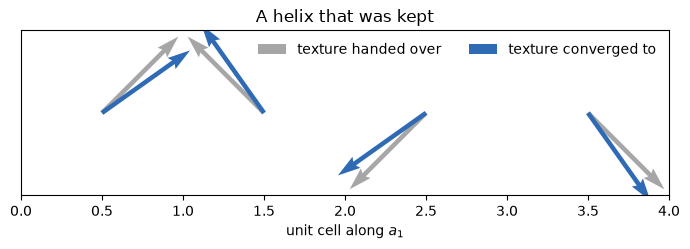

In [5]:
cells = np.arange(4) + 0.5
asked = np.stack([np.cos(2 * np.pi * cells / 4), np.sin(2 * np.pi * cells / 4)], -1)
got = np.stack([moments @ u, moments @ v], -1)
fig, ax = plt.subplots(figsize=(7, 2.6))
for arrows, colour, name in ((asked, '0.65', 'texture handed over'),
                             (got / np.linalg.norm(got, axis=1)[:, None],
                              '#2f6bb5', 'texture converged to')):
    ax.quiver(cells, np.zeros(4), arrows[:, 0], arrows[:, 1], color=colour,
              scale=6, width=0.007, label=name)
ax.set(xlim=(0, 4), ylim=(-0.75, 0.75), yticks=[],
       xlabel='unit cell along $a_1$', title='A helix that was kept')
ax.legend(frameon=False, loc='upper right', ncol=2); fig.tight_layout()

The two sets of arrows lie on top of each other and the four lengths agree to
six figures, so this is a uniform helix of exactly the pitch that was asked for
rather than four moments that happen to point in four directions.

**Read the tilt as well as the angle.** What the calculation adds to the texture
it was given is a small canting out of the helix plane, towards the direction
the unit cell's moment points in, the same in every cell. It is about a tenth of
the moment's length here, and it is a remnant of the ferromagnet the long cell
is expanded around: it halves to six degrees when the band count goes to
twenty-four and three at forty, while the ninety degrees per cell stays ninety
at every band count. The angle on its own would call the texture perfect while a
tenth of the moment pointed somewhere else, which is the useful lesson of the
pair.

The same band count controls the energy. The helix here is 0.30 mRy per cell
below the ferromagnet at sixteen bands and 0.49 at twenty-four, and a real
four-atom supercell started from the same four directions says 0.74, so the gain
is converging from below in the way everything else about the long cell does.
The number to quote is the one at the band count you ran.

## A long cell that prefers no direction

The tilt has a plain cause. The long cell is built out of the unit cell's own
states, and those carry spin along the unit cell's moment only: majority orbitals
with their spin along it and minority orbitals against it. Turning a moment away
from that direction needs a majority orbital with its spin reversed, which is not
among them, so the calculation leans back toward the direction it can represent.
Time reversal supplies exactly the missing states: the partner of every state of
the unit cell is the same orbital with its spin flipped, which is a state of the
unit cell with its moment reversed. Handed both sets, the long cell has nothing
to prefer.

Eight bands of each make the same number of states as the sixteen-band run above.

In [6]:
closed = spinor.get_ultracell(supercell=(4, 1, 1), kgrid=(1, 2, 2), nbnd=8,
                              seed_magnetization=texture, mixing_beta=0.3,
                              kramers_pairs=True)

moments = closed.cell_moments()
turned = np.unwrap(np.arctan2(moments @ v, moments @ u))
tilt = np.degrees(np.arcsin((moments @ axis) / np.linalg.norm(moments, axis=1)))
gain = (spinor.get_scf().total_energy - closed.total_energy) * 1000
print(f'{closed.iterations} iterations, turning',
      np.round(np.degrees(np.diff(turned)), 3), 'degrees per cell')
print(f'tilted out of the plane by {abs(tilt[0]):.3f} degrees, and {gain:.3f} mRy'
      ' per cell below the ferromagnet')

11 iterations, turning [90. 90. 90.] degrees per cell
tilted out of the plane by 0.000 degrees, and 0.738 mRy per cell below the ferromagnet


The tilt is gone, and so is most of the error in the energy: the helix now sits
0.738 mRy per cell below the ferromagnet, where the real four-atom supercell says
0.739 and the sixteen-band run of the same size said 0.30. The long cell's
problem is no larger than before; what changed is which states it is built
from. It also retires the advice about which axis to turn the texture about.
Without spin-orbit coupling the two sets together prefer no direction at all,
so a helix seeded about an axis the unit cell's moment does not point along
converges the same way, where the one set alone turns the whole texture into its
own frame first or settles into a helix that leans.

## What this does not do

The period is yours to choose and the calculation will not look for a better
one. A texture commensurate with the long cell is a solution of the long cell's
equations, and comparing the energies of several periods is how the best one is
found, one run each. Nothing here finds a period on its own, and a random
starting texture is a legitimate thing to hand over if that is what you want to
try.

The moments' plane is not entirely yours either, at least without spin-orbit
coupling: a rigid rotation of the whole texture costs nothing then, so the frame
the calculation settles in is the one the unit cell's states prefer, and with
their time-reversed partners it stays where it was put. With
spin-orbit coupling the anisotropy decides it instead, and that is physics
rather than arithmetic, which also means the pitch is free to relax and a
comparison against a supercell of the same length is the way to tell a texture
that relaxed from one that drifted.

The checks are in `tests/regression/test_ultracell.py`, where both waves are
compared against real supercells started from the same moments, and in
`tests/unit/test_ultracell_seed.py` for what the texture does to the
magnetization it is applied to.